## Outputs generados

**Etapa 1 — pre-entrenamiento sobre Snorkel (comparación de modelos):**
- `resultados/metricas_completas.csv` — métricas en el slice interno de Snorkel (comparación de modelos)
- `resultados/comparacion_modelos.png` — figura comparativa
- `resultados/curvas_entrenamiento.png` — curvas de entrenamiento
- `resultados/confusion_<modelo>.png` — matriz de confusión por modelo
- `resultados/mejor_modelo/` — modelo con mayor macro F1 (se afina en la etapa 2)

**Etapa 2 — fine-tuning sobre el golden con validación cruzada 5-fold (para el paper):**
- `resultados/metricas_cv_5fold.csv` — **métricas por fold (media ± desviación)**
- `resultados/metricas_cv_global.csv` — **reporte global out-of-fold sobre los 2k golden**
- `resultados/confusion_cv_oof.png` — **matriz de confusión out-of-fold (figura del paper)**


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas pyarrow matplotlib seaborn sentencepiece tiktoken

In [ ]:
import os, time, gc, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset

# ── Entorno ──────────────────────────────────────────────────────────────────
ENV = 'colab'
print(f'Entorno forzado a: {ENV}')

# ── GPU ───────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name}  ({gpu_mem:.1f} GB VRAM)')
    torch.backends.cudnn.benchmark = True     # acelera convoluciones repetidas
else:
    print('ADVERTENCIA: No se detectó GPU — el entrenamiento será muy lento.')
    print('  Activa el acelerador en: Entorno de ejecución → Cambiar tipo de entorno')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch {torch.__version__} | Device: {device}')

Entorno forzado a: colab
GPU: Tesla T4  (14.6 GB VRAM)
PyTorch 2.11.0+cu128 | Device: cuda


In [ ]:
# ── Autenticación en Hugging Face ─────────────────────────────────────────────
# Descomenta las siguientes líneas y ejecuta la celda si necesitas acceso a modelos restringidos como MentalBERT
# from huggingface_hub import notebook_login
# notebook_login()

## 1. Configuración — cambiar solo aquí

### Antes de ejecutar en Kaggle — sube el dataset

1. **Sube los archivos parquet como dataset en Kaggle**
   - Ve a [kaggle.com/datasets](https://www.kaggle.com/datasets) → **New Dataset**
   - Nombre sugerido: `riesgo-psicosocial` (debe coincidir con `KAGGLE_DATASET` abajo)
   - Sube estos dos archivos desde tu máquina local:
     - `dataset_transformer_train.parquet`
     - `dataset_transformer_val.parquet`
   - Haz clic en **Create** — espera a que termine de procesar

2. **Adjunta el dataset a tu notebook**
   - En el panel derecho del notebook → **+ Add Data**
   - Busca el dataset que acabas de crear → **Add**

3. **Activa el acelerador GPU**
   - Panel derecho → **Session options** → Accelerator: **GPU T4 x2** (o P100)

4. **Ejecuta todas las celdas** — el notebook detecta automáticamente el entorno Kaggle y lee desde `/kaggle/input/riesgo-psicosocial/`

> **Colab**: Si utilizas Colab, asegúrate de activar la GPU en: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU. La subida de los archivos parquet se debe realizar de manera **manual** al ejecutar la celda de abajo sin necesidad de Google Drive, y los resultados se guardarán directamente en la carpeta `/content/resultados`.

In [ ]:
# ============================================================
# MODELOS A COMPARAR
# ============================================================
MODELOS = {
    'BETO':        'dccuchile/bert-base-spanish-wwm-cased',
    #'RoBERTa-bne': 'PlanTL-GOB-ES/roberta-base-bne',
    #'XLM-RoBERTa': 'xlm-roberta-base',
    #'MentalBERT':  'mental/mental-bert-base-uncased', # Modelo restringido, requiere token de HF
    #'mDeBERTa-v3': 'microsoft/mdeberta-v3-base',
}

# ============================================================
# PATHS — exclusivo para Colab
# ============================================================
BASE_INPUT  = Path('/content')
BASE_OUTPUT = Path('/content/resultados')

BASE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f'Input:  {BASE_INPUT}')
print(f'Output: {BASE_OUTPUT}')

# ============================================================
# HIPERPARÁMETROS (iguales para todos — comparación justa)
# ============================================================
CFG = dict(
    train_file     = BASE_INPUT / 'dataset_transformer_train.csv',
    val_file       = BASE_INPUT / 'dataset_transformer_val.csv',
    test_file      = BASE_INPUT / 'dataset_transformer_test.csv',
    text_col       = 'texto',
    label_col      = 'snorkel_label',   # etiquetas débiles (Snorkel) — train
    label_col_eval = 'label_manual',    # etiquetas manuales (golden) — val y test
    num_labels     = 3,
    max_length   = 128,
    batch_size   = 16,
    lr           = 1e-5,   # bajado de 2e-5: evita overfitting a etiquetas ruidosas
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    num_epochs   = 8,   # subido de 5: con lr mas bajo necesita mas epochs
    patience     = 3,   # subido de 2: da mas tiempo para converger
    fp16         = torch.cuda.is_available(),
    seed         = SEED,
    output_base  = BASE_OUTPUT,
)

# 3 clases: Leve fusionado en Control (frontera léxicamente indetectable).
LABEL_NAMES = ['Control', 'Moderado', 'Crítico']

print(f'\nHiperparámetros:')
print(f'  batch_size={CFG["batch_size"]} | lr={CFG["lr"]} | max_length={CFG["max_length"]}')
print(f'  fp16={CFG["fp16"]} | patience={CFG["patience"]} | seed={CFG["seed"]}')


Input:  /content
Output: /content/resultados

Hiperparámetros:
  batch_size=16 | lr=1e-05 | max_length=128
  fp16=True | patience=3 | seed=42


In [ ]:
from google.colab import files

print("Sube los tres archivos CSV:")
print("  1. dataset_transformer_train.csv")
print("  2. dataset_transformer_val.csv")
print("  3. dataset_transformer_test.csv")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"  Archivo subido: {filename}")
    if 'train' in filename:
        CFG['train_file'] = BASE_INPUT / filename
    elif 'val' in filename:
        CFG['val_file'] = BASE_INPUT / filename
    elif 'test' in filename:
        CFG['test_file'] = BASE_INPUT / filename

print(f"\nCFG actualizado:")
print(f"  train_file : {CFG['train_file']}")
print(f"  val_file   : {CFG['val_file']}")
print(f"  test_file  : {CFG['test_file']}")

Sube los tres archivos CSV:
  1. dataset_transformer_train.csv
  2. dataset_transformer_val.csv
  3. dataset_transformer_test.csv


Saving dataset_transformer_train_1.csv to dataset_transformer_train_1.csv
Saving dataset_transformer_test.csv to dataset_transformer_test.csv
Saving dataset_transformer_val.csv to dataset_transformer_val.csv
  Archivo subido: dataset_transformer_train_1.csv
  Archivo subido: dataset_transformer_test.csv
  Archivo subido: dataset_transformer_val.csv

CFG actualizado:
  train_file : /content/dataset_transformer_train_1.csv
  val_file   : /content/dataset_transformer_val.csv
  test_file  : /content/dataset_transformer_test.csv


### Subida manual de archivos (solo Colab)

Sube los **tres** archivos CSV cuando se ejecute la celda de abajo:
`dataset_transformer_train.csv`, `dataset_transformer_val.csv` y `dataset_transformer_test.csv`.

## 2. Cargar datos

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Datos para el pipeline en 2 etapas con validación cruzada (5-fold) en el golden
#
#   Etapa 1 (pretrain): 104k Snorkel (3 clases). Early stopping con un slice
#                       INTERNO de Snorkel (NO toca el golden → sin leakage).
#   Etapa 2 (CV):       2k golden (val+test combinados). 5-fold estratificado.
#                       Cada ejemplo golden se evalúa exactamente una vez.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

MAP_3 = {0: 0, 1: 0, 2: 1, 3: 2}   # Leve(1)->Control(0); Moderado(2)->1; Crítico(3)->2

# ---- Train Snorkel (etiquetas débiles, ya en 3 clases 0-2) ----
df_train = pd.read_csv(CFG["train_file"])[[CFG["text_col"], CFG["label_col"]]].dropna()
df_train = df_train.rename(columns={CFG["text_col"]: "text", CFG["label_col"]: "label"})
df_train["text"]  = df_train["text"].astype(str)
df_train["label"] = df_train["label"].astype(int)

# Slice interno de Snorkel para early stopping de la etapa 1 (sin tocar el golden)
df_s_tr, df_s_val = train_test_split(
    df_train, test_size=0.05, stratify=df_train["label"], random_state=SEED
)
print(f"Etapa 1 — Snorkel train: {len(df_s_tr):,} | Snorkel val (early stop): {len(df_s_val):,}")

# ---- Golden 2k para CV (val + test combinados, remapeados a 3 clases) ----
def _carga_golden(path):
    d = pd.read_csv(path)
    if "label_manual_3c" in d.columns:           # ya viene en 3 clases
        d = d[[CFG["text_col"], "label_manual_3c"]].dropna()
        d = d.rename(columns={CFG["text_col"]: "text", "label_manual_3c": "label"})
        d["label"] = d["label"].astype(int)
    else:                                          # 4 clases → remapear
        d = d[[CFG["text_col"], CFG["label_col_eval"]]].dropna()
        d = d.rename(columns={CFG["text_col"]: "text", CFG["label_col_eval"]: "label"})
        d["label"] = d["label"].astype(int).map(MAP_3)
    d["text"] = d["text"].astype(str)
    return d

df_golden = pd.concat(
    [_carga_golden(CFG["val_file"]), _carga_golden(CFG["test_file"])],
    ignore_index=True
)
print(f"\nEtapa 2 — Golden combinado (val+test) para 5-fold CV: {len(df_golden):,}")
for i, name in enumerate(LABEL_NAMES):
    n = int((df_golden["label"] == i).sum())
    print(f"  {i} {name:10s}: {n:5,} ({n/len(df_golden)*100:.1f}%)")

# Compatibilidad con celdas de la etapa 1: val = slice interno de Snorkel.
# El golden NO se usa como test único (se evalúa por CV en la sección 11).
df_val  = df_s_val.copy()
df_test = None

# ---- Class weights de la etapa 1 (distribución Snorkel) ----
cw_snorkel = compute_class_weight("balanced",
                                  classes=np.arange(CFG["num_labels"]),
                                  y=df_s_tr["label"].values)
CLASS_WEIGHTS = torch.FloatTensor(cw_snorkel)
print(f"\nClass weights etapa 1 (Snorkel): {np.round(cw_snorkel, 3)}")


Etapa 1 — Snorkel train: 98,832 | Snorkel val (early stop): 5,202

Etapa 2 — Golden combinado (val+test) para 5-fold CV: 1,998
  0 Control   : 1,701 (85.1%)
  1 Moderado  :   213 (10.7%)
  2 Crítico   :    84 (4.2%)

Class weights etapa 1 (Snorkel): [  0.341  16.706 196.095]


In [ ]:
# Convertir a HuggingFace Dataset (etapa 1: train Snorkel, val = slice interno Snorkel)
hf_train = Dataset.from_pandas(df_s_tr.reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val.reset_index(drop=True))

print(f'HF Train: {hf_train}')
print(f'HF Val:   {hf_val}')


HF Train: Dataset({
    features: ['text', 'label'],
    num_rows: 98832
})
HF Val:   Dataset({
    features: ['text', 'label'],
    num_rows: 5202
})


## 3. Utilidades de entrenamiento

In [ ]:
def compute_metrics(eval_pred):
    """Metricas completas para el paper: macro F1 + por clase (3 clases)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    report = classification_report(
        labels, preds,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )
    return {
        "macro_f1":      report["macro avg"]["f1-score"],
        "weighted_f1":   report["weighted avg"]["f1-score"],
        "accuracy":      report["accuracy"],
        "f1_control":    report[LABEL_NAMES[0]]["f1-score"],
        "f1_moderado":   report[LABEL_NAMES[1]]["f1-score"],
        "f1_critico":    report[LABEL_NAMES[2]]["f1-score"],
        "prec_control":  report[LABEL_NAMES[0]]["precision"],
        "prec_critico":  report[LABEL_NAMES[2]]["precision"],
        "rec_critico":   report[LABEL_NAMES[2]]["recall"],
    }


class WeightedTrainer(Trainer):
    """Trainer con CrossEntropyLoss ponderada por clase (maneja desbalance)."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        # label_smoothing + weight causa CUDA illegal address en fp16; se omite
        loss = F.cross_entropy(
            outputs.logits, labels,
            weight=self.class_weights.to(outputs.logits.device),
        )
        return (loss, outputs) if return_outputs else loss


print("Utilidades OK")


Utilidades OK


In [ ]:
def entrenar_modelo(nombre, model_id, hf_train, hf_val, cfg, class_weights):
    """
    Entrena un modelo y retorna dict de métricas + historial de entrenamiento."""

    print(f'\n{"="*70}')
    print(f'  {nombre}  —  {model_id}')
    print(f'{"="*70}')

    t0 = time.time()
    output_dir = cfg['output_base'] / nombre.lower().replace('-', '_')

    # ---- Tokenizer + tokenización ----
    print('  Cargando tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    def tokenize(batch):
        return tokenizer(
            batch['text'],
            truncation=True,
            max_length=cfg['max_length'],
            padding=False,
        )

    cols_remove = [c for c in hf_train.column_names if c != 'label']
    tok_train = hf_train.map(tokenize, batched=True, remove_columns=cols_remove)
    tok_val   = hf_val.map(tokenize, batched=True, remove_columns=cols_remove)

    # ---- Modelo ----
    print('  Cargando modelo...')
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=cfg['num_labels'],
        ignore_mismatched_sizes=True,
    )

    total_steps = (len(tok_train) // cfg['batch_size']) * cfg['num_epochs']
    warmup_steps = int(total_steps * cfg['warmup_ratio'])

    training_args = TrainingArguments(
        output_dir               = str(output_dir),
        eval_strategy            = 'epoch',
        save_strategy            = 'epoch',
        learning_rate            = cfg['lr'],
        per_device_train_batch_size = cfg['batch_size'],
        per_device_eval_batch_size  = cfg['batch_size'] * 2,
        num_train_epochs         = cfg['num_epochs'],
        weight_decay             = cfg['weight_decay'],
        warmup_steps             = warmup_steps,
        load_best_model_at_end   = True,
        metric_for_best_model    = 'macro_f1',
        greater_is_better        = True,
        logging_steps            = 200,
        save_total_limit         = 1,
        fp16                     = cfg['fp16'],
        report_to                = 'none',
        seed                     = cfg['seed'],
        dataloader_num_workers   = 0,
    )

    trainer = WeightedTrainer(
        class_weights = class_weights,
        model         = model,
        args          = training_args,
        train_dataset = tok_train,
        eval_dataset  = tok_val,
        processing_class = tokenizer,
        data_collator = DataCollatorWithPadding(tokenizer),
        compute_metrics = compute_metrics,
        callbacks     = [EarlyStoppingCallback(early_stopping_patience=cfg['patience'])],
    )

    print('  Entrenando...')
    trainer.train()

    print('  Evaluando...')
    eval_res = trainer.evaluate()

    t_total = (time.time() - t0) / 60

    # Historial por época
    history = [
        e for e in trainer.state.log_history
        if 'eval_macro_f1' in e
    ]

    # Obtener predicciones para confusion matrix
    pred_out = trainer.predict(tok_val)
    preds_val = np.argmax(pred_out.predictions, axis=1)
    labels_val = pred_out.label_ids

    # Métricas (3 clases)
    metrics = {
        'modelo':         nombre,
        'model_id':       model_id,
        'macro_f1':       eval_res['eval_macro_f1'],
        'weighted_f1':    eval_res['eval_weighted_f1'],
        'accuracy':       eval_res['eval_accuracy'],
        'f1_control':     eval_res['eval_f1_control'],
        'f1_moderado':    eval_res['eval_f1_moderado'],
        'f1_critico':     eval_res['eval_f1_critico'],
        'prec_critico':   eval_res['eval_prec_critico'],
        'rec_critico':    eval_res['eval_rec_critico'],
        'tiempo_min':     round(t_total, 1),
    }

    print(f'\n  Macro F1: {metrics["macro_f1"]:.4f} | '
          f'F1-Crítico: {metrics["f1_critico"]:.4f} | '
          f'Tiempo: {t_total:.1f} min')

    return metrics, history, preds_val, labels_val, trainer, tokenizer


print('Función de entrenamiento lista')


Función de entrenamiento lista


## 3b. Optimización de hiperparámetros — PSO (Particle Swarm Optimization)

> **Esta sección es OPCIONAL.** Si la saltas, el entrenamiento usará los valores por defecto de CFG.
> Si la ejecutas, CFG se actualiza automáticamente con los mejores hiperparámetros encontrados.

### Estrategia
Se usa **PSO** (Kennedy & Eberhart, 1995) para buscar los hiperparámetros óptimos en un espacio continuo tridimensional:

| Dimensión | Rango | Descripción |
|---|---|---|
| `log10(lr)` | [-5.0, -4.0] | Learning rate: 1×10⁻⁵ a 1×10⁻⁴ |
| `weight_decay` | [0.00, 0.10] | Regularización L2 |
| `warmup_ratio` | [0.00, 0.20] | Fracción de pasos de warmup |

**Proxy rápido**: se evalúa solo BETO en 1 época con el 5% del train (~4k muestras).
Esto permite explorar el espacio en ~40-60 min antes del entrenamiento completo.
Los HPs encontrados se aplican a los 5 modelos para una comparación justa.

In [ ]:
# # Instalar pyswarms (solo si no está disponible)
# try:
#     import pyswarms as ps
#     print(f'pyswarms {ps.__version__} ya instalado.')
# except ImportError:
#     import subprocess, sys
#     subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyswarms'], check=True)
#     import pyswarms as ps
#     print(f'pyswarms instalado: {ps.__version__}')

# # ── Configuración PSO ─────────────────────────────────────────────────────────
# PSO_N_PARTICLES = 6      # tamaño del enjambre
# PSO_N_ITERS     = 4      # iteraciones (cada una evalúa N_PARTICLES modelos)
# PSO_FRAC        = 0.05   # fracción del train para evaluación proxy (≈4k muestras)
# PSO_PROXY       = 'dccuchile/bert-base-spanish-wwm-cased'  # modelo proxy (el más rápido)

# # Espacio de búsqueda: [log10(lr), weight_decay, warmup_ratio]
# PSO_LB = np.array([-5.0, 0.00, 0.00])
# PSO_UB = np.array([-4.0, 0.10, 0.20])

# # Opciones del enjambre (coeficientes estándar de Kennedy & Eberhart 1995)
# PSO_OPTIONS = {
#     'c1': 0.5,   # coeficiente cognitivo (atracción al mejor personal)
#     'c2': 0.3,   # coeficiente social    (atracción al mejor global)
#     'w':  0.9,   # inercia
# }

# # Dataset proxy
# df_pso_proxy = df_train.sample(frac=PSO_FRAC, random_state=SEED).reset_index(drop=True)
# hf_pso_proxy = Dataset.from_pandas(df_pso_proxy)
# total_evals  = PSO_N_PARTICLES * PSO_N_ITERS

# print(f'PSO configurado:')
# print(f'  Partículas={PSO_N_PARTICLES} | Iteraciones={PSO_N_ITERS} | '
#       f'Evaluaciones totales={total_evals}')
# print(f'  Muestras por eval: {len(df_pso_proxy):,}  ({PSO_FRAC*100:.0f}% del train)')
# print(f'  Tiempo estimado: ~{total_evals * 2}-{total_evals * 4} min en GPU T4')


# # ── Función de costo ──────────────────────────────────────────────────────────
# _pso_historia = []   # registro de todas las evaluaciones (para análisis posterior)

# def pso_cost(hyperparams_matrix):
#     """
#     Recibe matriz (n_particles, 3) con [log10_lr, weight_decay, warmup_ratio].
#     Retorna array (n_particles,) con costo = 1 - macro_F1.
#     Minimizar costo = maximizar macro F1.
#     """
#     n = hyperparams_matrix.shape[0]
#     costs = np.ones(n)   # default: costo máximo si falla

#     for i, particle in enumerate(hyperparams_matrix):
#         log_lr, wd, wr = float(particle[0]), float(particle[1]), float(particle[2])
#         lr_val = 10 ** log_lr

#         cfg_pso = CFG.copy()
#         cfg_pso.update({
#             'lr':           lr_val,
#             'weight_decay': wd,
#             'warmup_ratio': wr,
#             'num_epochs':   1,
#             'patience':     999,
#             'output_base':  CFG['output_base'] / '_pso_tmp',
#         })

#         try:
#             metricas, *_ = entrenar_modelo(
#                 f'pso_p{i:02d}', PSO_PROXY,
#                 hf_pso_proxy, hf_val, cfg_pso, CLASS_WEIGHTS
#             )
#             f1 = metricas['macro_f1']
#             costs[i] = 1.0 - f1
#             _pso_historia.append({'lr': lr_val, 'wd': wd, 'wr': wr, 'macro_f1': f1})
#             print(f'    [p{i:02d}] lr={lr_val:.2e}  wd={wd:.4f}  wr={wr:.4f}  '
#                   f'→ Macro F1={f1:.4f}  costo={costs[i]:.4f}')

#         except Exception as exc:
#             print(f'    [p{i:02d}] ERROR: {exc}')
#             _pso_historia.append({'lr': lr_val, 'wd': wd, 'wr': wr, 'macro_f1': None})

#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()

#     return costs


# print('\nFunción de costo PSO definida.')

In [ ]:
# # ── Ejecutar PSO ─────────────────────────────────────────────────────────────
# print('Iniciando PSO...')
# print(f'Espacio: lr=[1e-5, 1e-4]  wd=[0.00, 0.10]  wr=[0.00, 0.20]')
# print('-' * 60)

# t_pso_start = time.time()

# optimizer_pso = ps.single.GlobalBestPSO(
#     n_particles = PSO_N_PARTICLES,
#     dimensions  = 3,
#     options     = PSO_OPTIONS,
#     bounds      = (PSO_LB, PSO_UB),
# )
# best_cost_pso, best_pos_pso = optimizer_pso.optimize(
#     pso_cost, iters=PSO_N_ITERS, verbose=True
# )

# t_pso_min = (time.time() - t_pso_start) / 60

# # ── Extraer mejores hiperparámetros ──────────────────────────────────────────
# best_lr  = float(10 ** best_pos_pso[0])
# best_wd  = float(best_pos_pso[1])
# best_wr  = float(best_pos_pso[2])
# best_f1  = float(1.0 - best_cost_pso)

# print(f'\n{"="*60}')
# print(f'PSO completado en {t_pso_min:.1f} min')
# print(f'Mejores hiperparámetros (Macro F1 proxy = {best_f1:.4f}):')
# print(f'  learning_rate : {best_lr:.4e}  (era {CFG["lr"]:.4e})')
# print(f'  weight_decay  : {best_wd:.4f}  (era {CFG["weight_decay"]:.4f})')
# print(f'  warmup_ratio  : {best_wr:.4f}  (era {CFG["warmup_ratio"]:.4f})')

# # ── Actualizar CFG con los HPs óptimos ───────────────────────────────────────
# CFG['lr']           = best_lr
# CFG['weight_decay'] = best_wd
# CFG['warmup_ratio'] = best_wr
# print('\nCFG actualizado — los 5 modelos usarán estos hiperparámetros.')

# # ── Guardar historial de búsqueda ─────────────────────────────────────────────
# df_pso_hist = pd.DataFrame(_pso_historia).dropna()
# df_pso_hist = df_pso_hist.sort_values('macro_f1', ascending=False)
# df_pso_hist.to_csv(CFG['output_base'] / 'pso_historia.csv', index=False)
# print(f'\nTop 5 evaluaciones PSO:')
# print(df_pso_hist.head().to_string(index=False))

# # ── Gráfico de convergencia ───────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 4))
# costo_por_iter = optimizer_pso.cost_history
# ax.plot(range(1, len(costo_por_iter) + 1), costo_por_iter,
#         marker='o', color='steelblue', linewidth=2)
# ax.set_xlabel('Iteración PSO', fontsize=11)
# ax.set_ylabel('Mejor costo (1 - Macro F1)', fontsize=11)
# ax.set_title('Convergencia PSO — Optimización de hiperparámetros', fontsize=12)
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(CFG['output_base'] / 'pso_convergencia.png', dpi=200, bbox_inches='tight')
# plt.show()

## 4. Entrenar todos los modelos

Esto tarda ~15-40 min por modelo en GPU T4. Total estimado: **90-200 min**.

In [ ]:
todos_resultados = []   # métricas de cada modelo
todos_historiales = {}  # curvas de entrenamiento
todos_preds = {}        # predicciones val para confusion matrix
todos_trainers = {}     # trainers para guardar el mejor

mejor_f1 = 0.0
mejor_nombre = None
mejor_tokenizer = None

for nombre, model_id in MODELOS.items():
    try:
        metricas, hist, preds, labels, trainer, tokenizer = entrenar_modelo(
            nombre, model_id, hf_train, hf_val, CFG, CLASS_WEIGHTS
        )
        todos_resultados.append(metricas)
        todos_historiales[nombre] = hist
        todos_preds[nombre] = (preds, labels)
        todos_trainers[nombre] = trainer

        if metricas['macro_f1'] > mejor_f1:
            mejor_f1 = metricas['macro_f1']
            mejor_nombre = nombre
            mejor_tokenizer = tokenizer

            # Guardamos el mejor modelo a disco en este momento
            # antes de que sea borrado de memoria
            mejor_dir = CFG['output_base'] / 'mejor_modelo'
            trainer.save_model(str(mejor_dir))
            tokenizer.save_pretrained(str(mejor_dir))

        # Liberar memoria GPU entre modelos
        del trainer.model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    except Exception as exc:
        print(f'  [ERROR] {nombre}: {exc}')
        todos_resultados.append({'modelo': nombre, 'model_id': model_id, 'error': str(exc)})

print(f'\n\nMEJOR MODELO: {mejor_nombre} — Macro F1: {mejor_f1:.4f}')


  BETO  —  dccuchile/bert-base-spanish-wwm-cased
  Cargando tokenizer...


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

...

  Evaluando...


Training Loss,Validation Loss,Epoch,Macro F1,Weighted F1,Accuracy,F1 Control,F1 Moderado,F1 Critico,Prec Control,Prec Critico,Rec Critico
0.029343,0.348715,5,0.818748,0.990602,0.990581,0.995184,0.794393,0.666667,0.995478,0.833333,0.555556



  Macro F1: 0.8187 | F1-Crítico: 0.6667 | Tiempo: 52.0 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]



MEJOR MODELO: BETO — Macro F1: 0.8187


## 5. Tabla de resultados — tabla lista para el paper

In [ ]:

df_res = pd.DataFrame([r for r in todos_resultados if 'error' not in r])

if df_res.empty:
    print("⚠️ ADVERTENCIA: No hay resultados para mostrar. Todos los modelos fallaron durante el entrenamiento.")
    print("Por favor, revisa los logs de la celda de entrenamiento anterior (posible error de memoria GPU, falta de red, o error en los datos).")
else:
    cols_paper = ['modelo', 'accuracy', 'macro_f1', 'weighted_f1',
                  'f1_control', 'f1_moderado', 'f1_critico', 'tiempo_min']

    # Manejo por si alguna métrica falló y no está en la tabla
    cols_present = [c for c in cols_paper if c in df_res.columns]

    df_paper = df_res[cols_present].copy()

    # Formato %
    for c in cols_present:
        if c not in ['modelo', 'tiempo_min']:
            df_paper[c] = df_paper[c].map(lambda x: f'{x:.4f}' if isinstance(x, (int, float)) else x)

    print('=== TABLA DE RESULTADOS (val set) ===')
    print(df_paper.to_string(index=False))

    # Guardar CSV
    df_res.to_csv(CFG['output_base'] / 'metricas_completas.csv', index=False)
    print(f'\nGuardado: {CFG["output_base"]}/metricas_completas.csv')


=== TABLA DE RESULTADOS (val set) ===
modelo accuracy macro_f1 weighted_f1 f1_control f1_moderado f1_critico  tiempo_min
  BETO   0.9906   0.8187      0.9906     0.9952      0.7944     0.6667        52.0

Guardado: /content/resultados/metricas_completas.csv


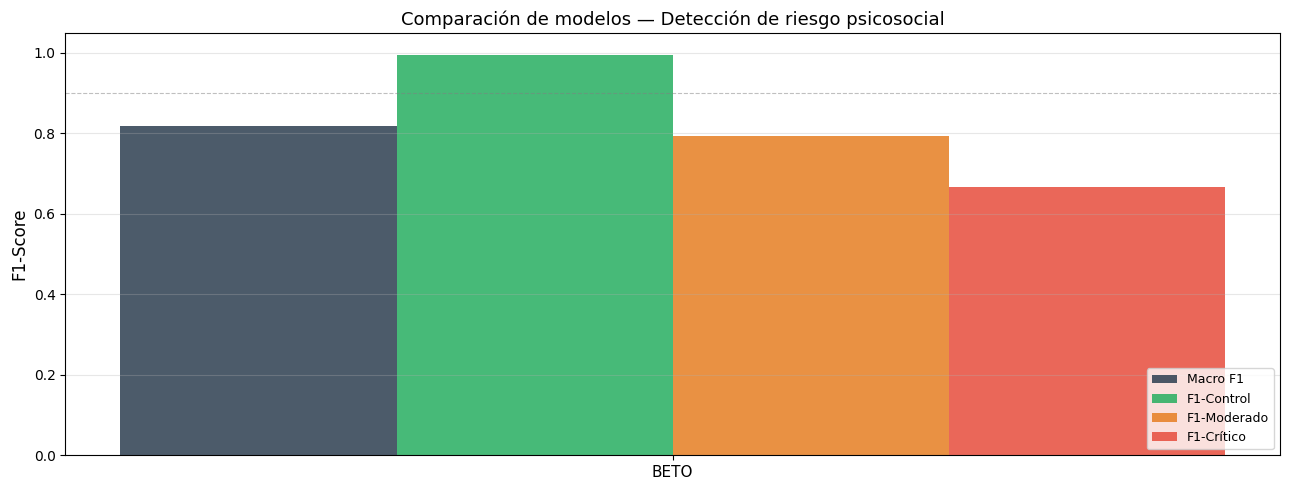

In [ ]:
# Gráfico comparativo de métricas — figura para el paper
if df_res.empty:
    print("No hay datos para graficar debido a los errores en el entrenamiento.")
else:
    # Solo las columnas que estén presentes
    cols_grafico = [c for c in ['macro_f1', 'f1_control', 'f1_moderado', 'f1_critico'] if c in df_res.columns]
    df_plot = df_res.set_index('modelo')[cols_grafico]

    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(df_plot))
    width = 0.18
    colors = ['#2c3e50', '#27ae60', '#e67e22', '#e74c3c'][:len(cols_grafico)]
    labels_bar = ['Macro F1', 'F1-Control', 'F1-Moderado', 'F1-Crítico'][:len(cols_grafico)]

    for i, (col, color, lbl) in enumerate(zip(df_plot.columns, colors, labels_bar)):
        ax.bar(x + i * width, df_plot[col], width, label=lbl, color=color, alpha=0.85)

    ax.set_xticks(x + width * (len(cols_grafico)/2 - 0.5))
    ax.set_xticklabels(df_plot.index, fontsize=11)
    ax.set_ylabel('F1-Score', fontsize=12)
    ax.set_title('Comparación de modelos — Detección de riesgo psicosocial', fontsize=13)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.tight_layout()
    plt.savefig(CFG['output_base'] / 'comparacion_modelos.png', dpi=200, bbox_inches='tight')
    plt.show()


## 6. Curvas de entrenamiento

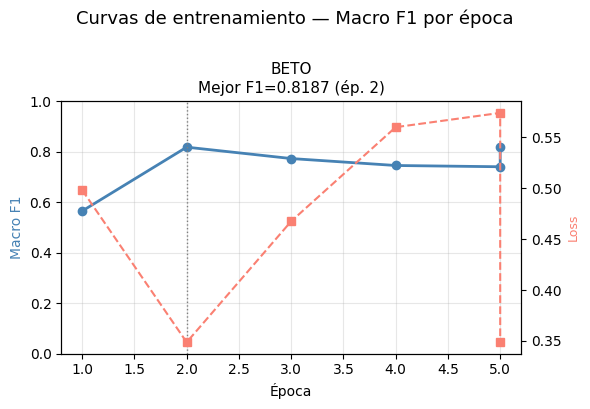

In [ ]:
n_modelos = len(todos_historiales)
cols_fig = min(3, n_modelos)
rows_fig = (n_modelos + cols_fig - 1) // cols_fig
fig, axes = plt.subplots(rows_fig, cols_fig, figsize=(6 * cols_fig, 4 * rows_fig))
axes = np.array(axes).flatten()

for i, (nombre, hist) in enumerate(todos_historiales.items()):
    epocas   = [h['epoch'] for h in hist]
    macro_f1 = [h['eval_macro_f1'] for h in hist]
    eval_loss = [h.get('eval_loss', None) for h in hist]

    ax = axes[i]
    ax.plot(epocas, macro_f1, marker='o', color='steelblue', label='Macro F1', linewidth=2)
    if any(v is not None for v in eval_loss):
        ax2 = ax.twinx()
        ax2.plot(epocas, eval_loss, marker='s', color='salmon', linestyle='--',
                 label='Val Loss', linewidth=1.5)
        ax2.set_ylabel('Loss', color='salmon', fontsize=9)

    mejor_ep = epocas[np.argmax(macro_f1)]
    mejor_val = max(macro_f1)
    ax.axvline(mejor_ep, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{nombre}\nMejor F1={mejor_val:.4f} (ép. {mejor_ep:.0f})', fontsize=11)
    ax.set_xlabel('Época')
    ax.set_ylabel('Macro F1', color='steelblue')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curvas de entrenamiento — Macro F1 por época', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(CFG['output_base'] / 'curvas_entrenamiento.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Matrices de confusión


  BETO


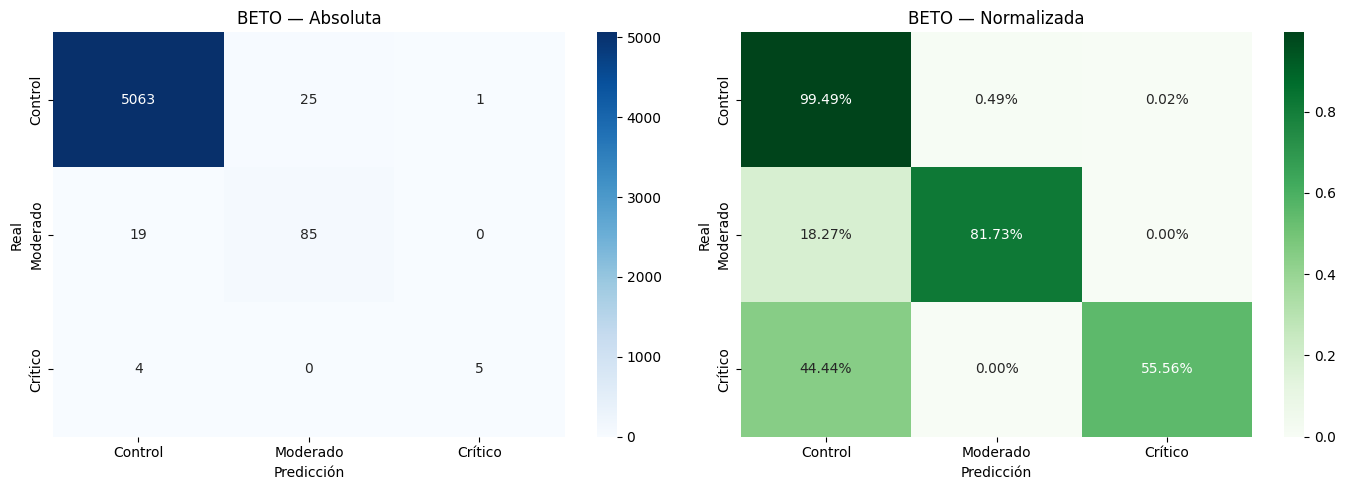

              precision    recall  f1-score   support

     Control     0.9955    0.9949    0.9952      5089
    Moderado     0.7727    0.8173    0.7944       104
     Crítico     0.8333    0.5556    0.6667         9

    accuracy                         0.9906      5202
   macro avg     0.8672    0.7893    0.8187      5202
weighted avg     0.9907    0.9906    0.9906      5202



In [ ]:
def plot_confusion_matrix(preds, labels, nombre, save_path=None):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
    axes[0].set_title(f'{nombre} — Absoluta', fontsize=12)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
    axes[1].set_title(f'{nombre} — Normalizada', fontsize=12)
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

    # Reporte por clase
    print(classification_report(labels, preds, target_names=LABEL_NAMES, digits=4))


for nombre, (preds, labels) in todos_preds.items():
    print(f'\n{"="*60}')
    print(f'  {nombre}')
    print(f'{"="*60}')
    plot_confusion_matrix(
        preds, labels, nombre,
        save_path=CFG['output_base'] / f'confusion_{nombre.lower().replace("-","_")}.png'
    )

## 8. Guardar mejor modelo

In [ ]:
if mejor_nombre is not None:
    mejor_dir = CFG['output_base'] / 'mejor_modelo'
    print(f'Mejor modelo previamente guardado en disco: {mejor_nombre} (Macro F1={mejor_f1:.4f})')
    print(f'Ruta: {mejor_dir}')

    # Guardar también un config.json con info del experimento
    import json
    info = {
        'mejor_modelo': mejor_nombre,
        'model_id': MODELOS[mejor_nombre],
        'macro_f1_val': round(mejor_f1, 4),
        'hiperparametros': {k: str(v) for k, v in CFG.items()},
    }
    with open(mejor_dir / 'experimento_info.json', 'w', encoding='utf-8') as f:
        json.dump(info, f, ensure_ascii=False, indent=2)
    print('Info del experimento guardada.')

Mejor modelo previamente guardado en disco: BETO (Macro F1=0.8187)
Ruta: /content/resultados/mejor_modelo
Info del experimento guardada.


## 9. Resumen final

In [ ]:
print('=' * 70)
print('RESUMEN DEL EXPERIMENTO')
print('=' * 70)
print(f'  Dataset train:     {len(df_train):,} comentarios')
print(f'  Dataset val:       {len(df_val):,} comentarios')
print(f'  Modelos evaluados: {len(todos_resultados)}')
print(f'  Mejor modelo:      {mejor_nombre} (Macro F1={mejor_f1:.4f})')
print()
print('Ranking por Macro F1:')
df_rank = df_res.sort_values('macro_f1', ascending=False)
for _, row in df_rank.iterrows():
    marker = ' <<< MEJOR' if row['modelo'] == mejor_nombre else ''
    print(f"  {row['modelo']:20s} Macro F1={row['macro_f1']:.4f}  "
          f"F1-Crit={row['f1_critico']:.4f}  {row['tiempo_min']:.0f} min{marker}")
print()
print('Archivos generados:')
for f in sorted(CFG['output_base'].rglob('*')):
    if f.is_file():
        print(f'  {f}')
print('=' * 70)
print()
print('SIGUIENTE PASO: cuando tengas el golden set (800 comentarios anotados')
print('manualmente), carga el mejor modelo y evalúa sobre ese test set para')
print('reportar las métricas finales en el paper.')

RESUMEN DEL EXPERIMENTO
  Dataset train:     104,034 comentarios
  Dataset val:       5,202 comentarios
  Modelos evaluados: 1
  Mejor modelo:      BETO (Macro F1=0.8187)

Ranking por Macro F1:
  BETO                 Macro F1=0.8187  F1-Crit=0.6667  52 min <<< MEJOR

Archivos generados:
  /content/resultados/beto/checkpoint-12354/config.json
  /content/resultados/beto/checkpoint-12354/model.safetensors
  /content/resultados/beto/checkpoint-12354/optimizer.pt
  /content/resultados/beto/checkpoint-12354/rng_state.pth
  /content/resultados/beto/checkpoint-12354/scaler.pt
  /content/resultados/beto/checkpoint-12354/scheduler.pt
  /content/resultados/beto/checkpoint-12354/tokenizer.json
  /content/resultados/beto/checkpoint-12354/tokenizer_config.json
  /content/resultados/beto/checkpoint-12354/trainer_state.json
  /content/resultados/beto/checkpoint-12354/training_args.bin
  /content/resultados/comparacion_modelos.png
  /content/resultados/confusion_beto.png
  /content/resultados/curvas_en

## 9b. Evaluación final sobre el TEST set

Las métricas de las secciones anteriores se calculan sobre **val**, que es el mismo
conjunto usado para early stopping y selección del mejor modelo → tienen sesgo optimista.

**Las métricas que deben ir en el paper son las de esta sección**: se evalúa el mejor
modelo sobre el conjunto **test** (no visto durante el entrenamiento ni la selección),
con F1 y soporte (nº de ejemplos) por clase, para ver dónde se pierde rendimiento
(típicamente en las clases minoritarias *Moderado* / *Crítico*).

In [ ]:
# ── Evaluación final sobre el TEST set con el mejor modelo ────────────────────
if 'df_test' in globals() and df_test is not None and mejor_nombre is not None:
    mejor_dir = CFG['output_base'] / 'mejor_modelo'

    tok_test   = AutoTokenizer.from_pretrained(str(mejor_dir))
    model_test = AutoModelForSequenceClassification.from_pretrained(str(mejor_dir)).to(device)
    model_test.eval()

    textos_test = df_test['text'].tolist()
    labels_test = df_test['label'].values
    preds_test  = []
    bs = 64
    with torch.no_grad():
        for i in range(0, len(textos_test), bs):
            lote = textos_test[i:i + bs]
            enc = tok_test(lote, truncation=True, max_length=CFG['max_length'],
                           padding=True, return_tensors='pt').to(device)
            logits = model_test(**enc).logits
            preds_test.extend(torch.argmax(logits, dim=1).cpu().tolist())
    preds_test = np.array(preds_test)

    # Reporte por clase — incluye 'support' = nº de ejemplos reales por clase
    print(f'=== EVALUACIÓN FINAL SOBRE TEST — {mejor_nombre} ===\n')
    print(classification_report(labels_test, preds_test,
                                target_names=LABEL_NAMES, digits=4))

    rep = classification_report(labels_test, preds_test, target_names=LABEL_NAMES,
                                output_dict=True, zero_division=0)
    print(f"Macro F1 (test):    {rep['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1 (test): {rep['weighted avg']['f1-score']:.4f}")
    print(f"Accuracy (test):    {rep['accuracy']:.4f}")

    # Guardar métricas de test para el paper
    df_test_metrics = pd.DataFrame(rep).transpose()
    ruta_test = CFG['output_base'] / 'metricas_test.csv'
    df_test_metrics.to_csv(ruta_test)
    print(f'\nGuardado: {ruta_test}')

    # Matriz de confusión sobre test
    plot_confusion_matrix(
        preds_test, labels_test, f'{mejor_nombre} (TEST)',
        save_path=CFG['output_base'] / 'confusion_test_mejor_modelo.png'
    )
else:
    print('Test no disponible o sin mejor modelo — se omite la evaluación final.')
    print('Sube dataset_transformer_test.csv y entrena para reportar métricas de test.')

Test no disponible o sin mejor modelo — se omite la evaluación final.
Sube dataset_transformer_test.csv y entrena para reportar métricas de test.


## 10. Ejemplos detectados por el transformer (por nivel)

Carga el mejor modelo guardado y muestra ejemplos reales de comentarios clasificados
en cada nivel de riesgo psicosocial (**Control, Leve, Moderado, Crítico**), con la
confianza (probabilidad softmax) que el modelo asignó a cada predicción.

> Usa el conjunto **test** si fue subido; de lo contrario usa el conjunto **val**.

In [ ]:
# ── Cargar el mejor modelo guardado y predecir ───────────────────────────────
mejor_dir = CFG['output_base'] / 'mejor_modelo'

# Conjunto a inspeccionar: test si existe, si no val
if 'df_test' in globals() and df_test is not None:
    df_ejemplos = df_test.copy()
    origen = 'test'
else:
    df_ejemplos = df_val.copy()
    origen = 'val'
print(f'Generando ejemplos sobre el conjunto: {origen}  ({len(df_ejemplos):,} comentarios)')

# Cargar modelo + tokenizer desde disco
tok_ej   = AutoTokenizer.from_pretrained(str(mejor_dir))
model_ej = AutoModelForSequenceClassification.from_pretrained(str(mejor_dir)).to(device)
model_ej.eval()

# Predicción por lotes
textos = df_ejemplos['text'].tolist()
pred_labels, pred_conf = [], []
bs = 64
with torch.no_grad():
    for i in range(0, len(textos), bs):
        lote = textos[i:i + bs]
        enc = tok_ej(lote, truncation=True, max_length=CFG['max_length'],
                     padding=True, return_tensors='pt').to(device)
        logits = model_ej(**enc).logits
        probs  = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        pred_labels.extend(pred.cpu().tolist())
        pred_conf.extend(conf.cpu().tolist())

df_ejemplos = df_ejemplos.reset_index(drop=True)
df_ejemplos['pred']       = pred_labels
df_ejemplos['confianza']  = np.round(pred_conf, 4)
df_ejemplos['pred_nivel'] = df_ejemplos['pred'].map(dict(enumerate(LABEL_NAMES)))
df_ejemplos['real_nivel'] = df_ejemplos['label'].map(dict(enumerate(LABEL_NAMES)))

print(f'Predicciones generadas con el mejor modelo: {mejor_nombre}')

Generando ejemplos sobre el conjunto: val  (5,202 comentarios)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicciones generadas con el mejor modelo: BETO


In [ ]:
# ── Mostrar ejemplos por nivel predicho ──────────────────────────────────────
N_POR_NIVEL = 5   # cuántos ejemplos mostrar por nivel
MAX_CHARS   = 160 # recortar textos largos para la visualización

filas_tabla = []
for nivel_id, nivel_nombre in enumerate(LABEL_NAMES):
    sub = df_ejemplos[df_ejemplos['pred'] == nivel_id]
    print(f'\n{"="*80}')
    print(f'  NIVEL {nivel_id} — {nivel_nombre}   ({len(sub):,} comentarios detectados)')
    print(f'{"="*80}')

    if sub.empty:
        print('  (sin ejemplos detectados en este nivel)')
        continue

    # Ejemplos más representativos = mayor confianza del modelo
    muestra = sub.sort_values('confianza', ascending=False).head(N_POR_NIVEL)
    for _, r in muestra.iterrows():
        txt = r['text'][:MAX_CHARS] + ('…' if len(r['text']) > MAX_CHARS else '')
        ok  = '✓' if r['pred'] == r['label'] else f'✗ (real: {r["real_nivel"]})'
        print(f'  [{r["confianza"]*100:5.1f}%] {ok}')
        print(f'      "{txt}"')
        filas_tabla.append({
            'pred_nivel': nivel_nombre,
            'confianza':  r['confianza'],
            'acierto':    r['pred'] == r['label'],
            'real_nivel': r['real_nivel'],
            'texto':      txt,
        })

# Tabla resumen + guardado
df_ejemplos_tabla = pd.DataFrame(filas_tabla)
ruta_ejemplos = CFG['output_base'] / 'ejemplos_detectados_por_nivel.csv'
df_ejemplos_tabla.to_csv(ruta_ejemplos, index=False)
print(f'\n\nTabla de ejemplos guardada en: {ruta_ejemplos}')

# Conteo de detecciones por nivel
print('\nResumen de comentarios detectados por nivel:')
for nivel_id, nivel_nombre in enumerate(LABEL_NAMES):
    n = int((df_ejemplos['pred'] == nivel_id).sum())
    print(f'  {nivel_nombre:10s}: {n:6,} ({n/len(df_ejemplos)*100:.1f}%)')


  NIVEL 0 — Control   (5,086 comentarios detectados)
  [100.0%] ✓
      "Dr cuanto le extrañamos"
  [100.0%] ✓
      "Excelente información Muchas gracias"
  [100.0%] ✓
      "💯💯💯👌"
  [100.0%] ✓
      "mos un medico x exelencia dios el me sano"
  [100.0%] ✓
      "Qué buena actriz larita😊"

  NIVEL 1 — Moderado   (110 comentarios detectados)
  [ 99.9%] ✓
      "@alfonsolopez5269 hola amigo q tiempo te demora la taquicardia"
  [ 99.9%] ✓
      "Cuando comienzas hacer mucho ejercicio por un tiempo el miedo a las taquicardia se va"
  [ 99.9%] ✓
      "Tengo la misma duda He ido a urgencias por taquicardias y a pesar de llegar a 150 ppm me dicen que es ansiedad y que es normal No sabia lo del electrocardiologo…"
  [ 99.9%] ✓
      "@milloriver90 no sé si a ti te pasa pero cuando yo duermo que duro rato durmiendo hasta que amanezca que me voy a despertar de la cama como que me dan taquicard…"
  [ 99.9%] ✓
      "En un ataque de ansiedad se dispara la concentración de adrenalina en sangre y

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  DIAGNÓSTICO: Acuerdo Snorkel vs etiquetas manuales
#  Requiere que val_file tenga columnas 'snorkel_label' Y 'label_manual'
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import cohen_kappa_score, classification_report

df_diag = pd.read_csv(CFG['val_file'])

# Verificar que existan ambas columnas
if 'snorkel_label' not in df_diag.columns or 'label_manual' not in df_diag.columns:
    print("⚠️  El archivo val no tiene ambas columnas — omitiendo diagnóstico.")
    print(f"   Columnas disponibles: {list(df_diag.columns)}")
else:
    df_diag = df_diag.dropna(subset=['snorkel_label', 'label_manual'])
    df_diag['snorkel_label'] = df_diag['snorkel_label'].astype(int)
    df_diag['label_manual']  = df_diag['label_manual'].astype(int)

    acuerdo = (df_diag['snorkel_label'] == df_diag['label_manual']).mean()
    kappa   = cohen_kappa_score(df_diag['snorkel_label'], df_diag['label_manual'])

    print("=" * 60)
    print("  DIAGNÓSTICO: Snorkel vs Etiquetas Manuales")
    print("=" * 60)
    print(f"  Comentarios analizados : {len(df_diag):,}")
    print(f"  Acuerdo simple         : {acuerdo:.1%}")
    print(f"  Cohen's Kappa          : {kappa:.3f}")
    print()

    # Interpretación del Kappa
    if kappa >= 0.80:
        interp = "✓ Casi perfecto — Snorkel está bien, revisar setup de entrenamiento"
    elif kappa >= 0.60:
        interp = "✓ Sustancial — Snorkel aceptable, considerar ajuste de LFs"
    elif kappa >= 0.40:
        interp = "⚠  Moderado — Snorkel tiene ruido real, revisar LFs de bucket"
    else:
        interp = "✗ Bajo — Snorkel muy ruidoso, hay que corregir LFs antes de entrenar"
    print(f"  Interpretación: {interp}")
    print()

    # Matriz de confusión Snorkel vs Manual
    LABEL_NAMES_LIST = ['Control', 'Leve', 'Moderado', 'Crítico']
    ct = pd.crosstab(
        df_diag['snorkel_label'], df_diag['label_manual'],
        rownames=['Snorkel →'], colnames=['← Manual']
    )
    ct.index   = [f"{i} {LABEL_NAMES_LIST[i]}" for i in ct.index]
    ct.columns = [f"{i} {LABEL_NAMES_LIST[i]}" for i in ct.columns]
    print(ct.to_string())
    print()

    # Desacuerdos por clase — para identificar qué clase falla más
    print("  Desacuerdo por clase (Snorkel ≠ Manual):")
    for i, name in enumerate(LABEL_NAMES_LIST):
        mask    = df_diag['snorkel_label'] == i
        if mask.sum() == 0:
            continue
        errores = (df_diag.loc[mask, 'snorkel_label'] != df_diag.loc[mask, 'label_manual']).sum()
        total   = mask.sum()
        print(f"    {name:10s}: {errores:4d} / {total:4d} errores ({errores/total:.1%})")
    print()

    # Recomendación automática
    print("─" * 60)
    if kappa >= 0.60:
        print("  RECOMENDACIÓN: Snorkel OK.")
        print("  → Usa val Snorkel (10K) para early stopping.")
        print("  → Usa tus 1K manuales solo para métricas finales del paper.")
    else:
        print("  RECOMENDACIÓN: Corregir LFs antes de entrenar.")
        print("  → Añade LFs para humor/elogios en buckets de riesgo alto.")
        print("  → Regenera Snorkel y vuelve a generar los splits.")
    print("=" * 60)


  DIAGNÓSTICO: Snorkel vs Etiquetas Manuales
  Comentarios analizados : 999
  Acuerdo simple         : 34.3%
  Cohen's Kappa          : 0.179

  Interpretación: ✗ Bajo — Snorkel muy ruidoso, hay que corregir LFs antes de entrenar

            0 Control  1 Leve  2 Moderado  3 Crítico
0 Control         166       5           3          0
1 Leve            102      61          12          0
2 Moderado        261      21          82          8
3 Crítico         216      16          12         34

  Desacuerdo por clase (Snorkel ≠ Manual):
    Control   :    8 /  174 errores (4.6%)
    Leve      :  114 /  175 errores (65.1%)
    Moderado  :  290 /  372 errores (78.0%)
    Crítico   :  244 /  278 errores (87.8%)

────────────────────────────────────────────────────────────
  RECOMENDACIÓN: Corregir LFs antes de entrenar.
  → Añade LFs para humor/elogios en buckets de riesgo alto.
  → Regenera Snorkel y vuelve a generar los splits.


## 11. Fine-tuning sobre el golden con validación cruzada (5-fold)

La etapa 1 entrenó el modelo con etiquetas **débiles de Snorkel** (104k). Aquí va la
**etapa 2**: se afina el modelo pre-entrenado sobre el **golden manual** (2k = val+test
combinados) usando **validación cruzada estratificada de 5 folds**.

| Etapa | Datos | Rol |
|---|---|---|
| 1 | 104k Snorkel | Pre-entrenamiento (early stopping con slice interno de Snorkel) |
| 2 | 2k golden, 5-fold | Fine-tuning + evaluación cruzada |

**Por qué CV y no un split único:** Crítico tiene solo ~84 ejemplos. Un test fijo de 300
(13 Crítico) da métricas inestables. Con 5-fold cada ejemplo se evalúa exactamente una vez
(predicciones *out-of-fold*) y se reporta **media ± desviación**, robusto para la clase rara.

> **Sin leakage:** la etapa 1 NO usa el golden (early stopping con un slice interno de
> Snorkel); en cada fold, el subconjunto de evaluación nunca participa en el fine-tuning
> ni en el early stopping de ese fold.


In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report
from scipy.special import softmax as _softmax
import shutil

assert mejor_nombre is not None, 'Primero corre la etapa 1 (seccion 4) para tener mejor_modelo.'
PRETRAIN_DIR = CFG['output_base'] / 'mejor_modelo'
CV_MODEL_DIR = CFG['output_base'] / 'mejor_modelo_cv'   # modelo final del CV

N_FOLDS = 5
CFG_FT = dict(lr=1e-5, batch_size=16, num_epochs=10, weight_decay=0.01,
              warmup_ratio=0.1, max_length=CFG['max_length'], patience=3)

tok_ft = AutoTokenizer.from_pretrained(str(PRETRAIN_DIR))

def _hf_tok(df):
    ds = Dataset.from_pandas(df.reset_index(drop=True))
    return ds.map(
        lambda b: tok_ft(b['text'], truncation=True,
                         max_length=CFG_FT['max_length'], padding=False),
        batched=True,
        remove_columns=[c for c in ds.column_names if c != 'label'],
    )

X = df_golden['text'].values
y = df_golden['label'].values
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.full(len(df_golden), -1, dtype=int)
oof_probs  = np.zeros((len(df_golden), CFG['num_labels']))
oof_true   = y.copy()
fold_metrics = []
best_cv_f1   = 0.0

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
    print(f'\n{"="*60}\n  FOLD {fold}/{N_FOLDS}\n{"="*60}')
    df_tr_full = df_golden.iloc[tr_idx]
    df_te      = df_golden.iloc[te_idx]

    df_tr, df_es = train_test_split(
        df_tr_full, test_size=0.15, stratify=df_tr_full['label'], random_state=SEED
    )

    cw = compute_class_weight('balanced', classes=np.arange(CFG['num_labels']),
                              y=df_tr['label'].values)
    cw = torch.FloatTensor(cw)

    model_ft = AutoModelForSequenceClassification.from_pretrained(
        str(PRETRAIN_DIR), num_labels=CFG['num_labels']
    )

    args_ft = TrainingArguments(
        output_dir                  = str(CFG['output_base'] / f'cv_fold{fold}'),
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        learning_rate               = CFG_FT['lr'],
        per_device_train_batch_size = CFG_FT['batch_size'],
        per_device_eval_batch_size  = CFG_FT['batch_size'] * 2,
        num_train_epochs            = CFG_FT['num_epochs'],
        weight_decay                = CFG_FT['weight_decay'],
        warmup_ratio                = CFG_FT['warmup_ratio'],
        load_best_model_at_end      = True,
        metric_for_best_model       = 'macro_f1',
        greater_is_better           = True,
        logging_steps               = 20,
        save_total_limit            = 1,
        fp16                        = CFG['fp16'],
        report_to                   = 'none',
        seed                        = SEED,
        dataloader_num_workers      = 0,
    )

    trainer_ft = WeightedTrainer(
        class_weights    = cw,
        model            = model_ft,
        args             = args_ft,
        train_dataset    = _hf_tok(df_tr),
        eval_dataset     = _hf_tok(df_es),
        processing_class = tok_ft,
        data_collator    = DataCollatorWithPadding(tok_ft),
        compute_metrics  = compute_metrics,
        callbacks        = [EarlyStoppingCallback(early_stopping_patience=CFG_FT['patience'])],
    )
    trainer_ft.train()

    pred_out = trainer_ft.predict(_hf_tok(df_te))
    preds    = np.argmax(pred_out.predictions, axis=1)
    oof_preds[te_idx] = preds
    oof_probs[te_idx] = _softmax(pred_out.predictions, axis=1)

    rep = classification_report(df_te['label'].values, preds, target_names=LABEL_NAMES,
                                output_dict=True, zero_division=0)
    fold_metrics.append({
        'fold':        fold,
        'macro_f1':    rep['macro avg']['f1-score'],
        'accuracy':    rep['accuracy'],
        'f1_control':  rep['Control']['f1-score'],
        'f1_moderado': rep['Moderado']['f1-score'],
        'f1_critico':  rep[LABEL_NAMES[2]]['f1-score'],
        'rec_critico': rep[LABEL_NAMES[2]]['recall'],
    })
    fold_f1 = fold_metrics[-1]['macro_f1']
    print(f"  Fold {fold}: Macro F1={fold_f1:.4f} | "
          f"F1-Critico={fold_metrics[-1]['f1_critico']:.4f} | "
          f"Recall-Critico={fold_metrics[-1]['rec_critico']:.4f}")

    # Guardar el mejor fold antes de borrar el modelo
    if fold_f1 > best_cv_f1:
        best_cv_f1 = fold_f1
        trainer_ft.save_model(str(CV_MODEL_DIR))
        tok_ft.save_pretrained(str(CV_MODEL_DIR))
        print(f"  -> Nuevo mejor fold (F1={best_cv_f1:.4f}), guardado en mejor_modelo_cv/")

    del trainer_ft.model, model_ft
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nValidacion cruzada completada.')
print(f'Mejor fold: Macro F1={best_cv_f1:.4f} -> guardado en {CV_MODEL_DIR}')




  FOLD 1/5


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Map:   0%|          | 0/1358 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/399 [00:00<?, ? examples/s]

  Fold 5: Macro F1=0.5451 | F1-Critico=0.3871 | Recall-Critico=0.7059

Validacion cruzada completada.
Mejor fold: Macro F1=0.6218 -> guardado en /content/resultados/mejor_modelo_cv


=== MÉTRICAS POR FOLD ===
 fold  macro_f1  accuracy  f1_control  f1_moderado  f1_critico  rec_critico
    1  0.621784  0.857500    0.927622     0.476190    0.461538     0.529412
    2  0.572863  0.860000    0.933333     0.410256    0.375000     0.352941
    3  0.587843  0.855000    0.931387     0.375000    0.457143     0.470588
    4  0.514908  0.834586    0.923754     0.309859    0.311111     0.437500
    5  0.545143  0.809524    0.901664     0.346667    0.387097     0.705882

=== RESUMEN 5-FOLD (media ± desviación) ===
  macro_f1      : 0.5685 ± 0.0408
  accuracy      : 0.8433 ± 0.0214
  f1_control    : 0.9236 ± 0.0128
  f1_moderado   : 0.3836 ± 0.0636
  f1_critico    : 0.3984 ± 0.0627
  rec_critico   : 0.4993 ± 0.1320

=== REPORTE GLOBAL (out-of-fold sobre los 2k golden) ===
              precision    recall  f1-score   support

     Control     0.9256    0.9218    0.9237      1701
    Moderado     0.4286    0.3521    0.3866       213
     Crítico     0.3256    0.5000    0.3944     

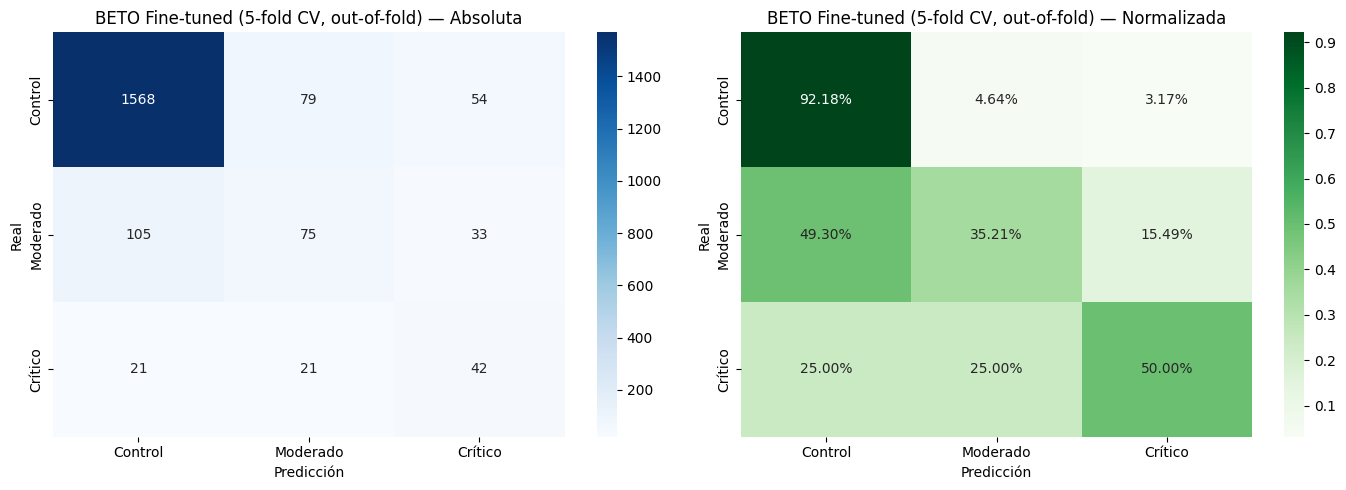

              precision    recall  f1-score   support

     Control     0.9256    0.9218    0.9237      1701
    Moderado     0.4286    0.3521    0.3866       213
     Crítico     0.3256    0.5000    0.3944        84

    accuracy                         0.8433      1998
   macro avg     0.5599    0.5913    0.5682      1998
weighted avg     0.8474    0.8433    0.8442      1998


Guardado:
  metricas_cv_5fold.csv   — métricas por fold
  metricas_cv_global.csv  — reporte global out-of-fold
  confusion_cv_oof.png    — matriz de confusión (para el paper)

RESULTADO PRINCIPAL — Macro F1 (5-fold): 0.5685 ± 0.0408


In [ ]:
# ── Resultados de la validación cruzada (5-fold) ──────────────────────────────
df_cv = pd.DataFrame(fold_metrics)
print('=== MÉTRICAS POR FOLD ===')
print(df_cv.to_string(index=False))

print('\n=== RESUMEN 5-FOLD (media ± desviación) ===')
resumen = {}
for col in ['macro_f1', 'accuracy', 'f1_control', 'f1_moderado', 'f1_critico', 'rec_critico']:
    m, s = df_cv[col].mean(), df_cv[col].std()
    resumen[col] = (m, s)
    print(f'  {col:14s}: {m:.4f} ± {s:.4f}')

# Reporte global sobre las predicciones out-of-fold (cada ejemplo evaluado 1 vez)
print('\n=== REPORTE GLOBAL (out-of-fold sobre los 2k golden) ===')
print(classification_report(oof_true, oof_preds, target_names=LABEL_NAMES, digits=4))

# Guardar métricas + matriz de confusión out-of-fold (la del paper)
df_cv.to_csv(CFG['output_base'] / 'metricas_cv_5fold.csv', index=False)
rep_oof = classification_report(oof_true, oof_preds, target_names=LABEL_NAMES,
                                output_dict=True, zero_division=0)
pd.DataFrame(rep_oof).transpose().to_csv(CFG['output_base'] / 'metricas_cv_global.csv')
plot_confusion_matrix(oof_preds, oof_true, 'BETO Fine-tuned (5-fold CV, out-of-fold)',
                      save_path=CFG['output_base'] / 'confusion_cv_oof.png')

print('\nGuardado:')
print('  metricas_cv_5fold.csv   — métricas por fold')
print('  metricas_cv_global.csv  — reporte global out-of-fold')
print('  confusion_cv_oof.png    — matriz de confusión (para el paper)')
print(f"\nRESULTADO PRINCIPAL — Macro F1 (5-fold): "
      f"{resumen['macro_f1'][0]:.4f} ± {resumen['macro_f1'][1]:.4f}")


## 11b. Gráficas de métricas adicionales

Curvas ROC, Precision-Recall, Precision/Recall/F1 por clase y estabilidad del CV.


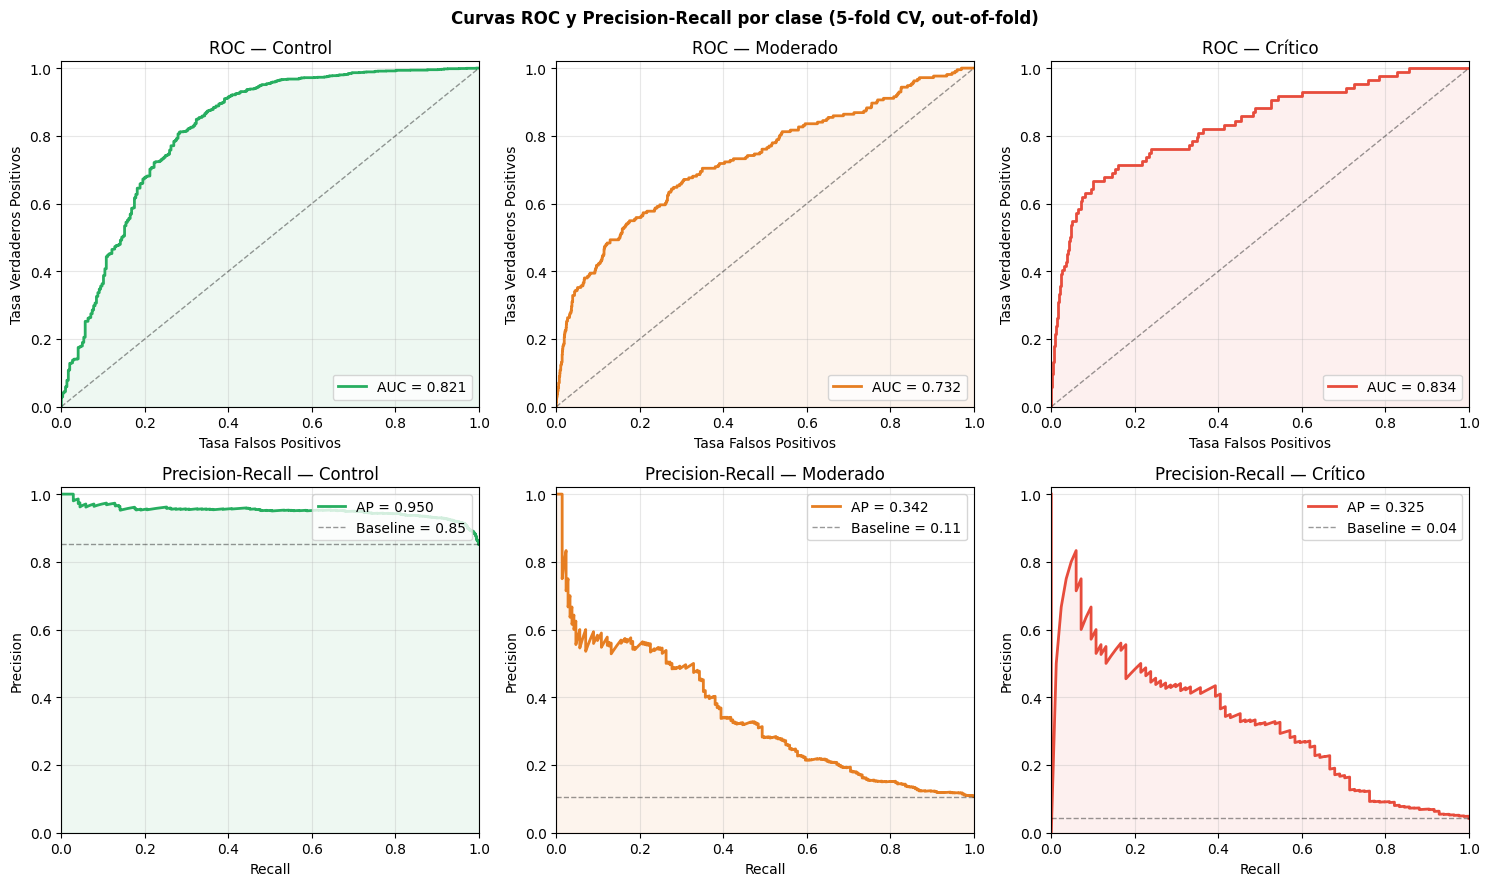

Guardado: /content/resultados/curvas_roc_pr.png
  Control    — AUC-ROC: 0.8207  |  AP: 0.9504
  Moderado   — AUC-ROC: 0.7315  |  AP: 0.3421
  Crítico    — AUC-ROC: 0.8335  |  AP: 0.3247


In [ ]:
# ── Curvas ROC y Precision-Recall (out-of-fold, usando oof_probs) ──────────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

if 'oof_probs' not in dir() or oof_probs.sum() == 0:
    print('oof_probs no disponible. Re-ejecuta el 5-fold CV para generarlas.')
else:
    y_bin   = label_binarize(oof_true, classes=list(range(CFG['num_labels'])))
    palette = ['#27ae60', '#e67e22', '#e74c3c']

    fig, axes = plt.subplots(2, CFG['num_labels'],
                             figsize=(5 * CFG['num_labels'], 9))
    fig.suptitle('Curvas ROC y Precision-Recall por clase (5-fold CV, out-of-fold)',
                 fontsize=12, fontweight='bold')

    for i, (name, col) in enumerate(zip(LABEL_NAMES, palette)):
        # ROC
        fpr, tpr, _ = roc_curve(y_bin[:, i], oof_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        axes[0, i].plot(fpr, tpr, color=col, lw=2, label=f'AUC = {roc_auc:.3f}')
        axes[0, i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
        axes[0, i].fill_between(fpr, tpr, alpha=0.08, color=col)
        axes[0, i].set_xlim([0, 1]); axes[0, i].set_ylim([0, 1.02])
        axes[0, i].set_xlabel('Tasa Falsos Positivos'); axes[0, i].set_ylabel('Tasa Verdaderos Positivos')
        axes[0, i].set_title(f'ROC — {name}')
        axes[0, i].legend(loc='lower right', fontsize=10)
        axes[0, i].grid(alpha=0.3)

        # Precision-Recall
        prec, rec, _ = precision_recall_curve(y_bin[:, i], oof_probs[:, i])
        ap            = average_precision_score(y_bin[:, i], oof_probs[:, i])
        baseline      = y_bin[:, i].mean()
        axes[1, i].plot(rec, prec, color=col, lw=2, label=f'AP = {ap:.3f}')
        axes[1, i].axhline(baseline, color='k', ls='--', lw=1, alpha=0.4,
                           label=f'Baseline = {baseline:.2f}')
        axes[1, i].fill_between(rec, prec, alpha=0.08, color=col)
        axes[1, i].set_xlim([0, 1]); axes[1, i].set_ylim([0, 1.02])
        axes[1, i].set_xlabel('Recall'); axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'Precision-Recall — {name}')
        axes[1, i].legend(loc='upper right', fontsize=10)
        axes[1, i].grid(alpha=0.3)

    plt.tight_layout()
    save_path = CFG['output_base'] / 'curvas_roc_pr.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {save_path}')

    for i, name in enumerate(LABEL_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], oof_probs[:, i])
        ap = average_precision_score(y_bin[:, i], oof_probs[:, i])
        print(f'  {name:10s} — AUC-ROC: {auc(fpr,tpr):.4f}  |  AP: {ap:.4f}')


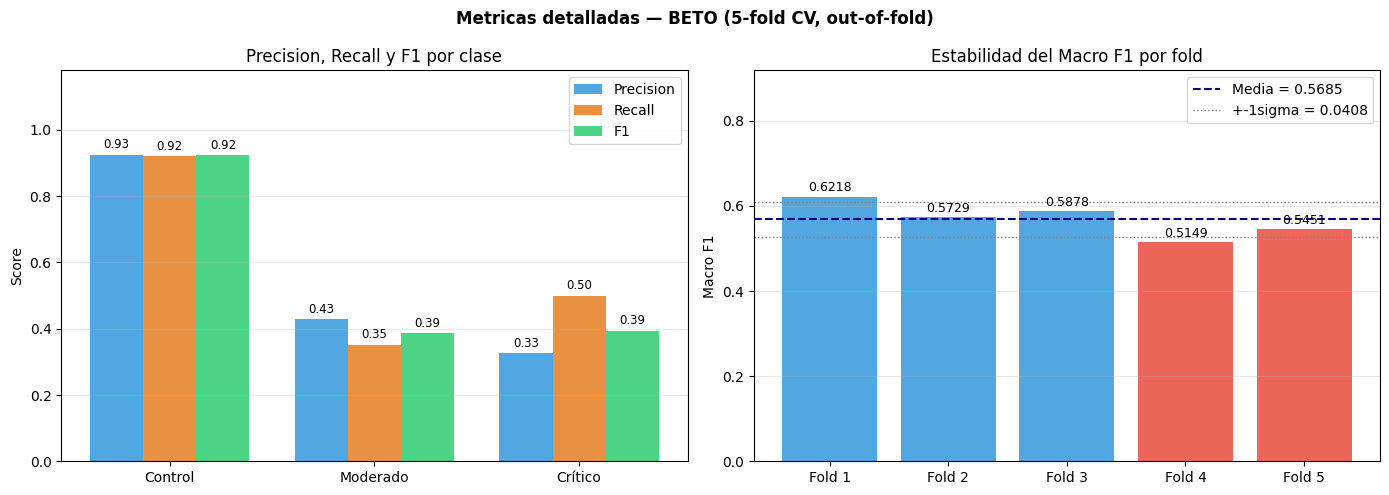

Guardado: /content/resultados/metricas_por_clase.png


In [ ]:
# ── Metricas por clase y estabilidad del CV ──────────────────────────────────
from sklearn.metrics import classification_report as _cr

rep = _cr(oof_true, oof_preds, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
df_cv_plot = pd.DataFrame(fold_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Metricas detalladas — BETO (5-fold CV, out-of-fold)', fontsize=12, fontweight='bold')

# — Precision / Recall / F1 por clase —
metric_keys = ['precision', 'recall', 'f1-score']
metric_labels = ['Precision', 'Recall', 'F1']
x = np.arange(len(LABEL_NAMES))
w = 0.26
bar_colors = ['#3498db', '#e67e22', '#2ecc71']
for j, (key, lbl, col) in enumerate(zip(metric_keys, metric_labels, bar_colors)):
    vals = [rep[cls][key] for cls in LABEL_NAMES]
    bars = axes[0].bar(x + j * w, vals, w, label=lbl, color=col, alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01, f'{val:.2f}',
                     ha='center', va='bottom', fontsize=8.5)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(LABEL_NAMES)
axes[0].set_ylim([0, 1.18])
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall y F1 por clase')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# — Estabilidad por fold —
mean_f1 = df_cv_plot['macro_f1'].mean()
std_f1  = df_cv_plot['macro_f1'].std()
fold_cols = ['#3498db' if v >= mean_f1 else '#e74c3c' for v in df_cv_plot['macro_f1']]
bars2 = axes[1].bar([f'Fold {i+1}' for i in range(len(fold_metrics))],
                    df_cv_plot['macro_f1'], color=fold_cols, alpha=0.85)
axes[1].axhline(mean_f1, color='navy', ls='--', lw=1.5, label=f'Media = {mean_f1:.4f}')
axes[1].axhline(mean_f1 - std_f1, color='gray', ls=':', lw=1)
axes[1].axhline(mean_f1 + std_f1, color='gray', ls=':', lw=1, label=f'+-1sigma = {std_f1:.4f}')
for bar, val in zip(bars2, df_cv_plot['macro_f1']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim([0, min(1.0, mean_f1 + 0.35)])
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Estabilidad del Macro F1 por fold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = CFG['output_base'] / 'metricas_por_clase.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {save_path}')


In [ ]:
def predict_riesgo(text, model, tokenizer):
    """Predice el nivel de riesgo psicosocial de un texto."""
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=CFG['max_length'],
        return_tensors='pt'
    )
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
        model   = model.cuda()

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
        probs  = torch.nn.functional.softmax(logits, dim=-1)[0]
        pred   = torch.argmax(probs).item()

    return {
        'class':         pred,
        'label':         LABEL_NAMES[pred],
        'confidence':    probs[pred].item(),
        'probabilities': probs.cpu().numpy(),
    }


# ── Seleccionar modelo: CV (fine-tuned) > Etapa 1 (Snorkel) ─────────────────
_cv_dir  = CFG['output_base'] / 'mejor_modelo_cv'
_e1_dir  = CFG['output_base'] / 'mejor_modelo'

if _cv_dir.exists():
    _pred_dir  = _cv_dir
    _pred_name = 'BETO Fine-tuned CV (golden)'
elif _e1_dir.exists():
    _pred_dir  = _e1_dir
    _pred_name = 'BETO Etapa 1 (Snorkel)  <-- re-ejecuta el CV para usar el modelo fino'
else:
    _pred_dir  = None
    _pred_name = None

if _pred_dir is None:
    print('ERROR: no se encontro ningun modelo. Ejecuta primero la Etapa 1.')
else:
    _tok   = AutoTokenizer.from_pretrained(str(_pred_dir))
    _model = AutoModelForSequenceClassification.from_pretrained(
        str(_pred_dir), num_labels=CFG['num_labels']
    )

    test_examples = [
        'Excelente video doctor, muy clara la explicacion, muchas gracias.',
        'jajaja que gracioso ese momento, lo mejor del video xD',
        'Llevo semanas sin dormir bien, me siento vacio y sin energia para nada.',
        'La ansiedad me tiene agotado, ya no puedo mas con todo esto.',
        'Ya no quiero seguir viviendo asi, siento que seria mejor desaparecer.',
        'Pienso todo el tiempo en hacerme dano, no encuentro ninguna razon para vivir.',
        'Tengo ansiedad.',
    ]

    BARRA   = '=' * 90
    DIVIDER = '-' * 90
    RISK_TAG = {0: '[OK]   ', 1: '[WARN] ', 2: '[CRIT] '}

    print('\n' + BARRA)
    print(f'  PREDICCIONES — {_pred_name}')
    print(BARRA)

    for i, text in enumerate(test_examples, 1):
        r = predict_riesgo(text, _model, _tok)
        tag = RISK_TAG[r['class']]
        print(f'\n  Ejemplo {i}: "{text[:80]}{"..." if len(text)>80 else ""}')
        print(DIVIDER)
        print(f'  {tag}  {r["label"]:10s}  Confianza: {r["confidence"]:.1%}')
        print('  Distribucion de probabilidad:')
        for j, name in enumerate(LABEL_NAMES):
            pct  = r['probabilities'][j] * 100
            bar  = '#' * int(pct / 2)
            mark = ' <--' if j == r['class'] else ''
            print(f'    {name:10s} {pct:5.1f}%  |{bar:<50}|{mark}')

    print('\n' + BARRA)
    print('  Para probar tu propio texto, edita la lista test_examples arriba.')
    print(BARRA)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  PREDICCIONES — BETO Fine-tuned CV (golden)

  Ejemplo 1: "Excelente video doctor, muy clara la explicacion, muchas gracias.
------------------------------------------------------------------------------------------
  [OK]     Control     Confianza: 99.6%
  Distribucion de probabilidad:
    Control     99.6%  |################################################# | <--
    Moderado     0.3%  |                                                  |
    Crítico      0.0%  |                                                  |

  Ejemplo 2: "jajaja que gracioso ese momento, lo mejor del video xD
------------------------------------------------------------------------------------------
  [OK]     Control     Confianza: 99.8%
  Distribucion de probabilidad:
    Control     99.8%  |################################################# | <--
    Moderado     0.2%  |                                                  |
    Crítico      0.0%  |                                                  |

  Ejemplo 3:

In [ ]:
import shutil
from pathlib import Path
from google.colab import files

# Prefiere el modelo fine-tuned con golden (CV); si no existe usa Etapa 1
_cv_dir = CFG['output_base'] / 'mejor_modelo_cv'
_e1_dir = CFG['output_base'] / 'mejor_modelo'

if _cv_dir.exists():
    _dl_dir   = _cv_dir
    _dl_label = 'mejor_modelo_cv  (Fine-tuned CV — golden)'
    _zip_name = 'mejor_modelo_cv'
elif _e1_dir.exists():
    _dl_dir   = _e1_dir
    _dl_label = 'mejor_modelo  (Etapa 1 — Snorkel)  <-- ejecuta el CV para descargar el fino'
    _zip_name = 'mejor_modelo'
else:
    _dl_dir = None

if _dl_dir is None:
    print('ERROR: no hay modelo guardado. Ejecuta primero la Etapa 1.')
else:
    zip_path = Path(f'/content/{_zip_name}')
    shutil.make_archive(str(zip_path), 'zip', str(_dl_dir.parent), _dl_dir.name)
    zip_final = Path(str(zip_path) + '.zip')

    total_mb = sum(f.stat().st_size for f in _dl_dir.rglob('*') if f.is_file()) / 1e6
    print(f'Modelo: {_dl_label}  ({total_mb:.0f} MB)')
    print('Archivos incluidos:')
    for f in sorted(_dl_dir.iterdir()):
        if f.is_file():
            print(f'  {f.name:<40} {f.stat().st_size/1e6:.1f} MB')

    print(f'\nZIP: {zip_final.name}  ({zip_final.stat().st_size/1e6:.1f} MB)')
    print('Descargando...')
    files.download(str(zip_final))

    folder = 'mejor_modelo_cv' if _cv_dir.exists() else 'mejor_modelo'
    print('\nListo. Pasos para activar el demo:')
    print(f'  1. Descomprime {_zip_name}.zip')
    print(f'  2. Mueve la carpeta {folder}/ a:')
    print( '       train_transformrs/resultados/mejor_modelo/')
    print( '  3. Ejecuta iniciar_demo.bat')
    print( '  4. Abre http://localhost:8000')


Modelo: mejor_modelo_cv  (Fine-tuned CV — golden)  (440 MB)
Archivos incluidos:
  config.json                              0.0 MB
  model.safetensors                        439.4 MB
  tokenizer.json                           0.7 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB

ZIP: mejor_modelo_cv.zip  (408.1 MB)
Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Listo. Pasos para activar el demo:
  1. Descomprime mejor_modelo_cv.zip
  2. Mueve la carpeta mejor_modelo_cv/ a:
       train_transformrs/resultados/mejor_modelo/
  3. Ejecuta iniciar_demo.bat
  4. Abre http://localhost:8000
